In [1]:
import os
import copy
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
datapath = "/data/users4/xli/MSIVA/MSIVA/results/sim_iter150_v20k_snr1k"
corr_list = []
isi_list = []

for gtss in range(1,6):
    ss_dir = f"gt_s{gtss}_test_s{gtss}"
    data = sio.loadmat(os.path.join(datapath,ss_dir,"Yinit.mat"))
    Yinit_um = data["Yinit_um"]
    Yinit_ummm = data["Yinit_ummm"]
    Yinit_mm = data["Yinit_mm"]
    corr_um = np.corrcoef(Yinit_um)
    corr_ummm = np.corrcoef(Yinit_ummm)
    corr_mm = np.corrcoef(Yinit_mm)
    corr_list.append([corr_um,corr_ummm,corr_mm])
    isi = sio.loadmat(os.path.join(datapath,ss_dir,"isi.mat"))
    isi_um = isi["isi_um"][0,0]
    isi_ummm = isi["isi_ummm"][0,0]
    isi_mm = isi["isi_mm"][0,0]
    isi_list.append([isi_um,isi_ummm,isi_mm])

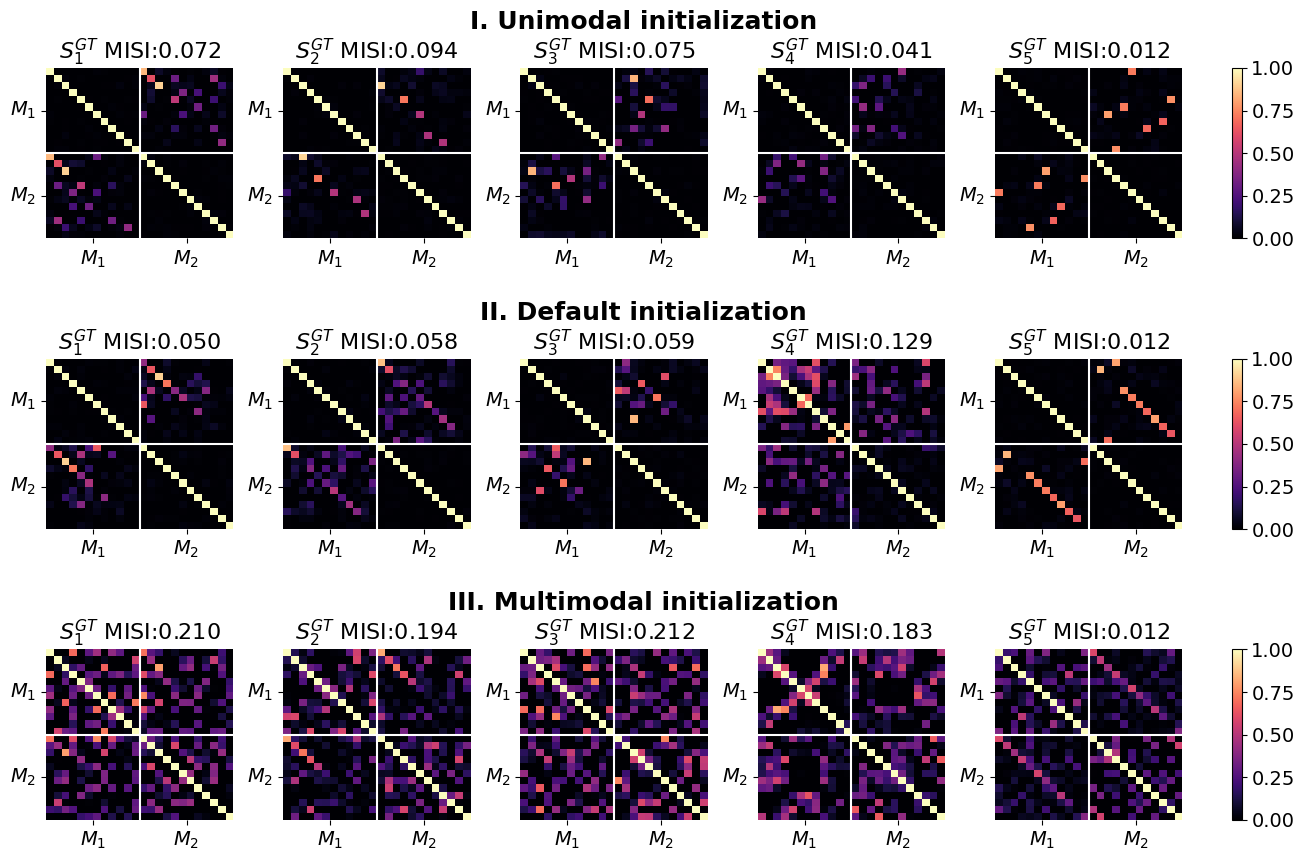

In [7]:
n_source = 12
ss_list = ["$S_1^{{GT}}$","$S_2^{{GT}}$","$S_3^{{GT}}$","$S_4^{{GT}}$","$S_5^{{GT}}$"]
wf_list = ["I. Unimodal initialization", "II. Default initialization", "III. Multimodal initialization"]

fig, axes = plt.subplots(3, 6, figsize=(13, 9), gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 0.05]})
for j in range(5):
    for i in range(3):
        ax = axes[i,j]
        corr = corr_list[j][i]
        sns.heatmap(corr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
        ax.set_title(f"{ss_list[j]} MISI:{isi_list[j][i]:.3f}", fontsize=16)
        ax.axvline(x=n_source, ymin=0, ymax=n_source*2, color="white")
        ax.axhline(y=n_source, xmin=0, xmax=n_source*2, color="white")
        ax.set_xticks([6, 18], labels=['$M_1$', '$M_2$'], rotation=0, fontsize=14)
        ax.set_yticks([6, 18], labels=['$M_1$', '$M_2$'], rotation=0, fontsize=14)

norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap="magma", norm=norm)

for i in range(3):
    ax = fig.add_subplot(3, 1, i+1)
    ax.set_title(wf_list[i], fontsize=18, fontweight='bold', pad=28)
    ax.axis('off')
    cbar = fig.colorbar(sm, cax=axes[i, 5])
    cbar.ax.tick_params(labelsize=14)

plt.tight_layout(pad=1, h_pad=0, w_pad=1)
plt.savefig("figures/init_corr.pdf")